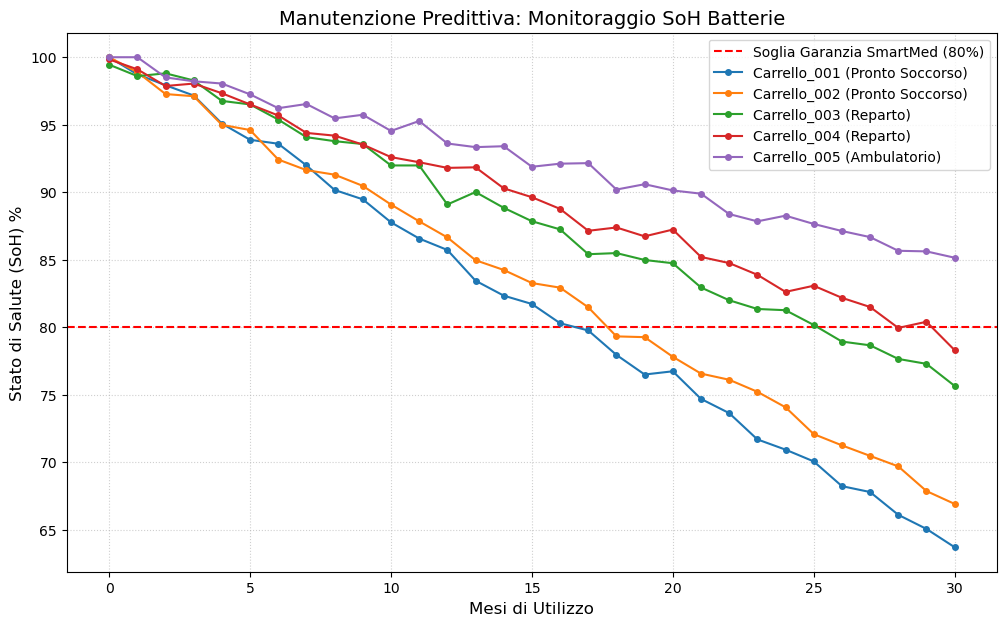

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



months = np.arange(0, 31) 
np.random.seed(42)

usage_profiles = {
    "Carrello_001 (Pronto Soccorso)": 1.2, # Alta intensità
    "Carrello_002 (Pronto Soccorso)": 1.1,
    "Carrello_003 (Reparto)": 0.8,         # Media intensità
    "Carrello_004 (Reparto)": 0.7,
    "Carrello_005 (Ambulatorio)": 0.5      # Bassa intensità
}

data = {"Mese": months}
for cart, rate in usage_profiles.items():
    # Simuliamo il decadimento del SoH (State of Health) con un po' di variabilità statistica
    noise = np.random.normal(0, 0.5, len(months))
    soh = 100 - (rate * months) + noise
    data[cart] = np.clip(soh, 0, 100)

df = pd.DataFrame(data)

# creazione grafico
plt.figure(figsize=(12, 7))

plt.axhline(y=80, color='red', linestyle='--', label='Soglia Garanzia SmartMed (80%)')

for cart in usage_profiles.keys():
    plt.plot(df['Mese'], df[cart], marker='o', markersize=4, label=cart)

plt.title('Manutenzione Predittiva: Monitoraggio SoH Batterie', fontsize=14)
plt.xlabel('Mesi di Utilizzo', fontsize=12)
plt.ylabel('Stato di Salute (SoH) %', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)